In [12]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import numpy as np
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


In [42]:



def compute_exploration_metrics(
    actions,
    n_arms=None,
    window_size=10,
    alpha=0.5
):
    """
    Compute rolling exploration metrics for multiple patients.

    Parameters
    ----------
    actions : torch.Tensor or np.ndarray
        Shape:
            (n_patients, n_trials)

        Contains arm selections.

    n_arms : int
        Total number of arms.
        If None -> inferred automatically.

    window_size : int
        Rolling window size.

    alpha : float
        Weight for combined exploration score.

        combined_score =
            alpha * entropy +
            (1-alpha) * switching_rate

    Returns
    -------
    results : dict

        {
            'entropy': tensor (n_patients, T-window+1),
            'switching': tensor (n_patients, T-window+1),
            'combined_score': tensor (n_patients, T-window+1),
            'mean_entropy': tensor (n_patients,),
            'mean_switching': tensor (n_patients,),
            'mean_combined': tensor (n_patients,)
        }
    """

    # convert to tensor
    if isinstance(actions, np.ndarray):
        actions = torch.tensor(actions)

    actions = actions.long()

    n_patients, n_trials = actions.shape

    if n_arms is None:
        n_arms = int(actions.max().item()) + 1

    out_len = n_trials - window_size + 1

    entropy_all = torch.zeros((n_patients, out_len))
    switching_all = torch.zeros((n_patients, out_len))

    # max entropy normalization
    max_entropy = np.log(n_arms)

    for p in range(n_patients):

        patient_actions = actions[p]

        for t in range(out_len):

            w = patient_actions[t:t + window_size]

            # -------------------------
            # entropy
            # -------------------------
            counts = torch.bincount(
                w,
                minlength=n_arms
            ).float()

            probs = counts / counts.sum()

            probs = probs[probs > 0]

            entropy = -(probs * torch.log(probs)).sum()

            # normalize entropy
            entropy = entropy / max_entropy

            entropy_all[p, t] = entropy

            # -------------------------
            # switching rate
            # -------------------------
            switches = (
                w[1:] != w[:-1]
            ).float().mean()

            switching_all[p, t] = switches

    # combined exploration score
    combined = (
        alpha * entropy_all +
        (1 - alpha) * switching_all
    )

    results = {
        "entropy": entropy_all,
        "switching": switching_all,
        "combined_score": combined,
        "mean_entropy": entropy_all.mean(dim=1),
        "mean_switching": switching_all.mean(dim=1),
        "mean_combined": combined.mean(dim=1)
    }

    return results

## NSB

In [48]:
# Case-1
data_normal_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v1_normal.pkl')

with open(data_normal_file_v1, 'rb') as f:
    data_normal_v1 = pickle.load(f)

print(data_normal_v1.keys())

# load PD

data_PD_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v1_PD.pkl')

with open(data_PD_file_v1, 'rb') as f:
    data_PD_v1 = pickle.load(f)

# load std_DBS

data_std_DBS_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v1_std_DBS.pkl')

with open(data_std_DBS_file_v1, 'rb') as f:
    data_std_DBS_v1 = pickle.load(f)

# load sector_DBS

data_sector_DBS_file_v1 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v1_sector_DBS.pkl')

with open(data_sector_DBS_file_v1, 'rb') as f:
    data_sector_DBS_v1 = pickle.load(f)


dict_keys(['DP_AVG', 'IP_AVG', 'AVG_CARD_PICKS_PER_BIN', 'ARM_CHOSEN_MONITOR', 'REWARD_MONITOR', 'OPTIMAL_PROBS_PER_BIN', 'LAST_BIN_PROBS', 'MEAN_PROB', 'MEAN_REWARD'])


In [62]:

exp_res_normal = compute_exploration_metrics(
    data_normal_v1["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_normal["mean_combined"]), torch.mean(exp_res_normal["mean_entropy"]), torch.mean(exp_res_normal["mean_switching"])) # for 100 patients


exp_res_PD = compute_exploration_metrics(
    data_PD_v1["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_PD["mean_combined"]), torch.mean(exp_res_PD["mean_entropy"]), torch.mean(exp_res_PD["mean_switching"])) # for 100 patients


exp_res_std_DBS = compute_exploration_metrics(
    data_std_DBS_v1["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_std_DBS["mean_combined"]), torch.mean(exp_res_std_DBS["mean_entropy"]), torch.mean(exp_res_std_DBS["mean_switching"])) # for 100 patients



exp_res_sector_DBS = compute_exploration_metrics(
    data_sector_DBS_v1["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_sector_DBS["mean_combined"]), torch.mean(exp_res_sector_DBS["mean_entropy"]), torch.mean(exp_res_sector_DBS["mean_switching"])) # for 100 patients




tensor(0.1220) tensor(0.1468) tensor(0.0641)
tensor(0.0197) tensor(0.0254) tensor(0.0062)
tensor(0.0525) tensor(0.0657) tensor(0.0217)
tensor(0.1190) tensor(0.1445) tensor(0.0595)


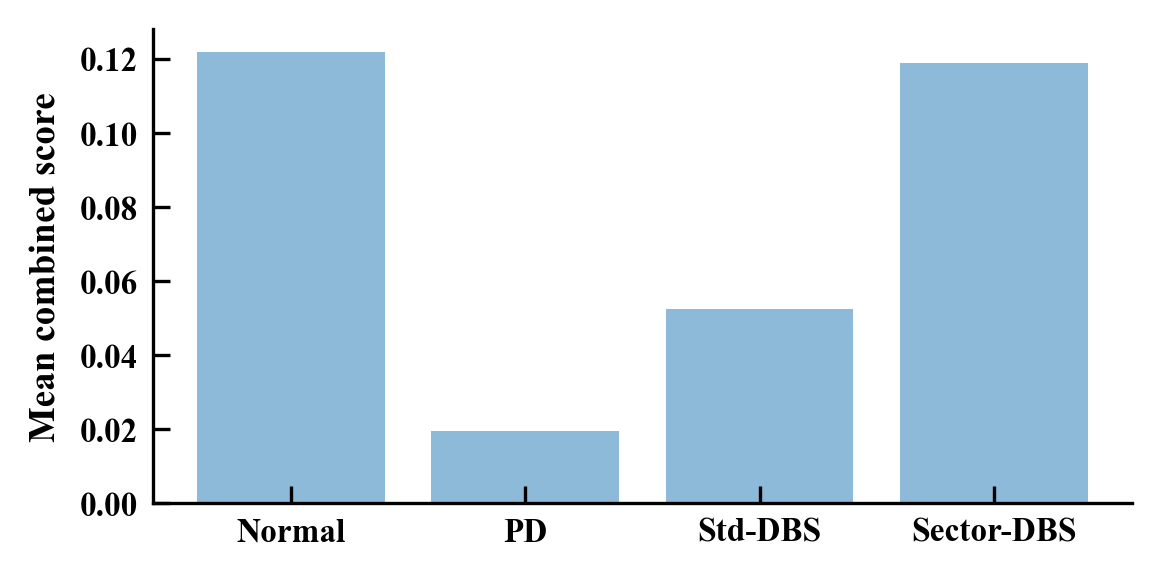

In [63]:
# Plot bar plot mean combined for normal, pd, std dbs sector dbs
plt.figure(figsize=(4,2))

labels = ['Normal', 'PD', 'Std-DBS', 'Sector-DBS']
data = [torch.mean(exp_res_normal["mean_combined"]), torch.mean(exp_res_PD["mean_combined"]), torch.mean(exp_res_std_DBS["mean_combined"]), torch.mean(exp_res_sector_DBS["mean_combined"])]
x = np.arange(len(labels))  # the label locations
plt.bar(x, data, align='center', alpha=0.5)
plt.xticks(x, labels)

plt.ylabel('Mean combined score')
plt.tight_layout()



# NSB V2

In [68]:
data_normal_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v2_normal.pkl')

with open(data_normal_file_v2, 'rb') as f:
    data_normal_v2 = pickle.load(f)

print(data_normal_v2.keys())

# load PD

data_PD_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v2_PD.pkl')

with open(data_PD_file_v2, 'rb') as f:
    data_PD_v2 = pickle.load(f)

# load std_DBS

data_std_DBS_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v2_std_DBS.pkl')

with open(data_std_DBS_file_v2, 'rb') as f:
    data_std_DBS_v2 = pickle.load(f)

# load sector_DBS

data_sector_DBS_file_v2 = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'non_stationary_bandits', 'non_stationary_bandits_v2_sector_DBS.pkl')

with open(data_sector_DBS_file_v2, 'rb') as f:
    data_sector_DBS_v2 = pickle.load(f)




dict_keys(['DP_AVG', 'IP_AVG', 'AVG_CARD_PICKS_PER_BIN', 'ARM_CHOSEN_MONITOR', 'REWARD_MONITOR', 'OPTIMAL_PROBS_PER_BIN', 'LAST_BIN_PROBS', 'MEAN_PROB', 'MEAN_REWARD'])


In [69]:

exp_res_normal = compute_exploration_metrics(
    data_normal_v2["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_normal["mean_combined"]), torch.mean(exp_res_normal["mean_entropy"]), torch.mean(exp_res_normal["mean_switching"])) # for 100 patients


exp_res_PD = compute_exploration_metrics(
    data_PD_v2["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_PD["mean_combined"]), torch.mean(exp_res_PD["mean_entropy"]), torch.mean(exp_res_PD["mean_switching"])) # for 100 patients


exp_res_std_DBS = compute_exploration_metrics(
    data_std_DBS_v2["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_std_DBS["mean_combined"]), torch.mean(exp_res_std_DBS["mean_entropy"]), torch.mean(exp_res_std_DBS["mean_switching"])) # for 100 patients



exp_res_sector_DBS = compute_exploration_metrics(
    data_sector_DBS_v2["ARM_CHOSEN_MONITOR"],
    n_arms=3,
    window_size=15,
    alpha=0.7
)
print(torch.mean(exp_res_sector_DBS["mean_combined"]), torch.mean(exp_res_sector_DBS["mean_entropy"]), torch.mean(exp_res_sector_DBS["mean_switching"])) # for 100 patients




tensor(0.0813) tensor(0.0949) tensor(0.0495)
tensor(0.0121) tensor(0.0157) tensor(0.0036)
tensor(0.0126) tensor(0.0154) tensor(0.0059)
tensor(0.0990) tensor(0.1151) tensor(0.0614)


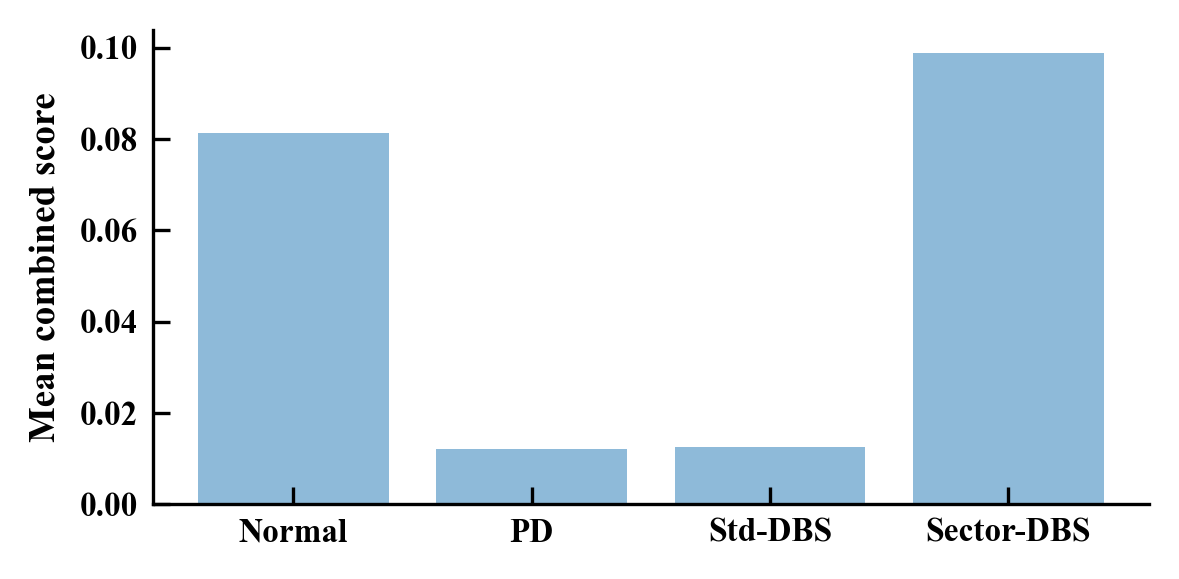

In [70]:
# Plot bar plot mean combined for normal, pd, std dbs sector dbs
plt.figure(figsize=(4,2))

labels = ['Normal', 'PD', 'Std-DBS', 'Sector-DBS']
data = [torch.mean(exp_res_normal["mean_combined"]), torch.mean(exp_res_PD["mean_combined"]), torch.mean(exp_res_std_DBS["mean_combined"]), torch.mean(exp_res_sector_DBS["mean_combined"])]
x = np.arange(len(labels))  # the label locations
plt.bar(x, data, align='center', alpha=0.5)
plt.xticks(x, labels)

plt.ylabel('Mean combined score')
plt.tight_layout()



# RB

In [71]:
lat_arr = [0.0275]
del_lim_arr = [1.0]
Mean_PD_all = []
Mean_std_DBS_all = []
Mean_sector_DBS_all = []

for i in range(len(lat_arr)):
    lat_str = str(lat_arr[i]).replace('.', '_')
    if i == 1:
        data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'restless_bandits_data_lat_'+ lat_str + '_1.pkl')
        with open(data_file, 'rb') as f:
            data = pickle.load(f)
    elif i == 0:
        data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'restless_bandits_data_lat_'+ lat_str + '_2.pkl')
        with open(data_file, 'rb') as f:
            data = pickle.load(f)
    else:
        data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'restless_bandits_data_lat_'+ lat_str + '.pkl')
        with open(data_file, 'rb') as f:
            data = pickle.load(f)
    del_lim_arr = data['DEL_LIM_ARR']
    lat_strength = data['LAT_STRENGTH']
    prob_optimal_monitor = data['PROB_OPTIMAL_MONITOR']
    mean_prob_monitor = data['MEAN_PROB_MONITOR']
    Mean_Probs_PD = [mean_prob_monitor['PD'][del_lim] for del_lim in del_lim_arr]
    Mean_Probs_std_DBS = [mean_prob_monitor['STD_DBS'][del_lim] for del_lim in del_lim_arr]
    Mean_Probs_sector_DBS = [mean_prob_monitor['SECTOR_DBS'][del_lim] for del_lim in del_lim_arr]

    Mean_PD_all.append(Mean_Probs_PD)
    Mean_std_DBS_all.append(Mean_Probs_std_DBS)
    Mean_sector_DBS_all.append(Mean_Probs_sector_DBS)
        

FileNotFoundError: [Errno 2] No such file or directory: '/Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making/results/decision_making_tasks/data/restless_bandits/restless_bandits_data_lat_0_0275_2.pkl'

In [72]:
data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'all_cases_data.pkl')
with open(data_file, 'rb') as f:
    data = pickle.load(f)

In [75]:
data.keys()

dict_keys(['DEL_LIM_ARR', 'VAR_ARR', 'VAR', 'ARM_MONITOR', 'NUM_ARM_PICKS_MONITOR', 'DP_MONITOR', 'IP_MONITOR', 'REWARD_MONITOR', 'ARM_TRACKER', 'OPTIMAL_CHOICE_MONITOR', 'ACTUAL_CHOICE_MONITOR', 'PROB_OPTIMAL_MONITOR', 'MEAN_PROB_MONITOR'])

In [76]:
data['DEL_LIM_ARR']

[0.1, 0.2, 0.5, 1.0]

In [77]:
data['ARM_MONITOR']

defaultdict(dict,
            {0.01: {0.1: tensor([[0., 1., 2.,  ..., 0., 0., 0.],
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      ...,
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      [0., 1., 2.,  ..., 0., 0., 0.],
                      [0., 1., 1.,  ..., 0., 0., 0.]]),
              0.2: tensor([[0., 1., 2.,  ..., 0., 0., 0.],
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      ...,
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      [0., 1., 2.,  ..., 0., 0., 0.],
                      [0., 1., 2.,  ..., 0., 0., 0.]]),
              0.5: tensor([[0., 1., 1.,  ..., 0., 0., 0.],
                      [0., 1., 2.,  ..., 0., 0., 0.],
                      [0., 1., 1.,  ..., 0., 0., 0.],
                      ...,
                      [0., 1., 1.,  ..., 0., 0., 0.],
            